1) Escreva um algoritmo que usa a rotina que sobrescreve uma matriz A por uma representação de sua fatoração LU sem troca de linhas (dada em aula) para resolver um sistema linear nxn. 

2) Use seu algoritmo para resolver o sistema linear Ax=b, onde A=[1 1 0 3;2 1 -1 1;3 -1 -1 2;-1 2 3 -1] e b=[8;7;14;-7].

3) Adapte os códigos anteriores para desenvolver uma rotina que calcula a fatoração PA=LU e outra para resolver um sistema linear Ax=b utilizando esta fatoração. Represente a matriz de permutação P como uma permutação do vetor [1;2;...;n].

4) Faça passo a passo um exemplo numérico onde A=[0 1 -1 1;1 1 -1 2;-1 -1 1 0;1 2 0 2] e b=[8;-20;-2;4].

Use qualquer linguagem de programação e entregue os códigos juntamente com um relatório. Tudo em pdf.

# Lógica + Teoria:

## Exercício 1:

In [ ]:
"""
1) Escreva um algoritmo que usa a rotina que sobrescreve uma matriz A por uma representação de sua 
fatoração LU sem troca de linhas (dada em aula) para resolver um sistema linear nxn.
"""

# Deve ser matriz quadrada e singular (invertível).
# Seria possível testar isso antes, mas, como não foi pedido, assumi que sempre receberá input correto.

    # Eliminacao de Gauss
        # Coluna vai ate n - 1, uma a menos
            # Linha vai ate n
                # Calcula fator alfa dividindo pelo pivo
                # Guarda L, fator alfa sobrescreve a posicao da matriz A

                # Linha vai ate n
                    # O k comeca em j + 1 pois NAO PRECISAMOS calcular subtracao do pivo: sabemos que vai dar zero
                        # Guarda U, subtracao de linhas sobrescreve a posicao da matriz A


    # Resolvendo Ly = b
        # Somatoria de 0 a n
                # Calcula a somatoria de matriz[i,j] * y[j]
            # O y daquela posicao sera o vetor b da posicao - a somatoria ate ali


    # Resolvendo Ux = y
    # Mesma logica, mas comeca por baixo e sobe

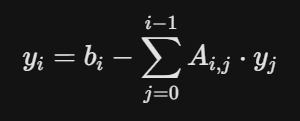

### Teoria:

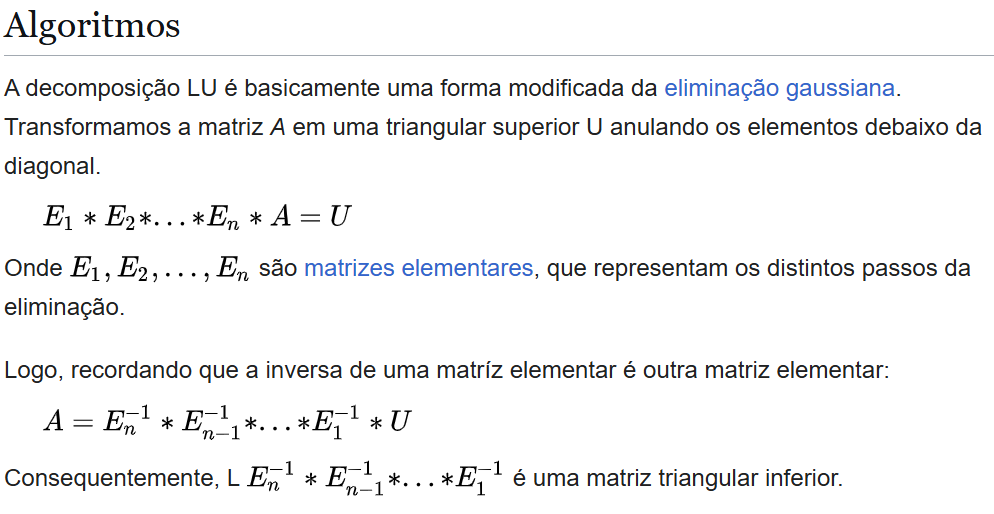

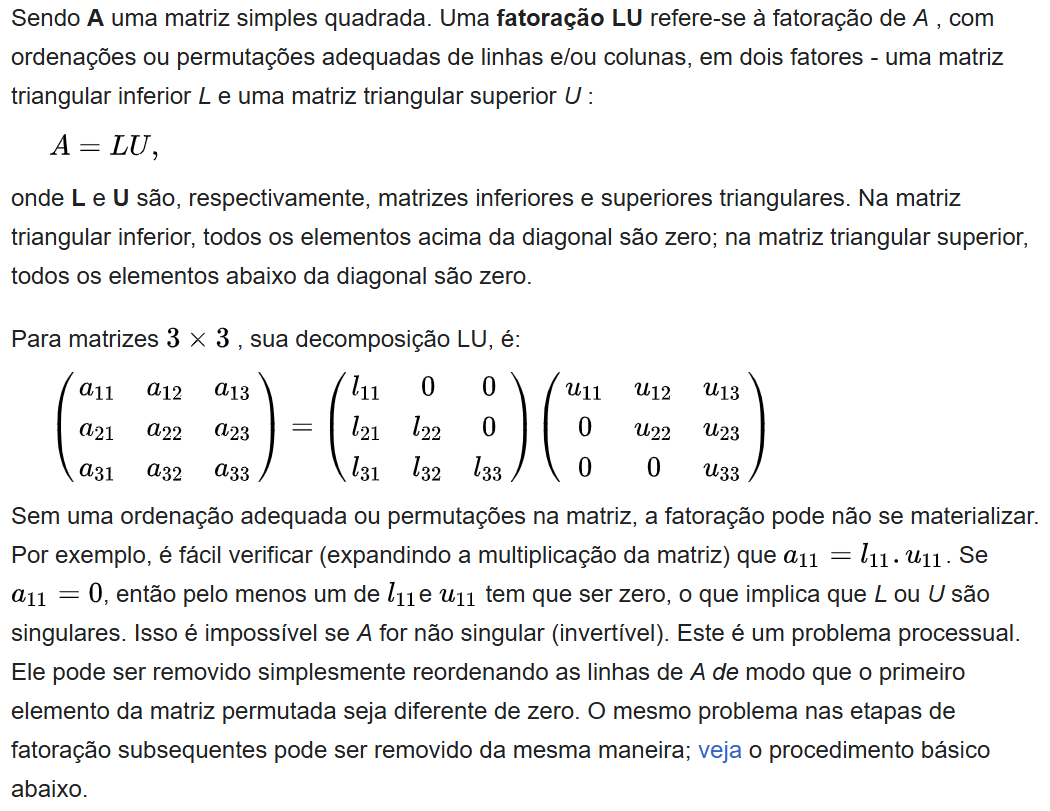

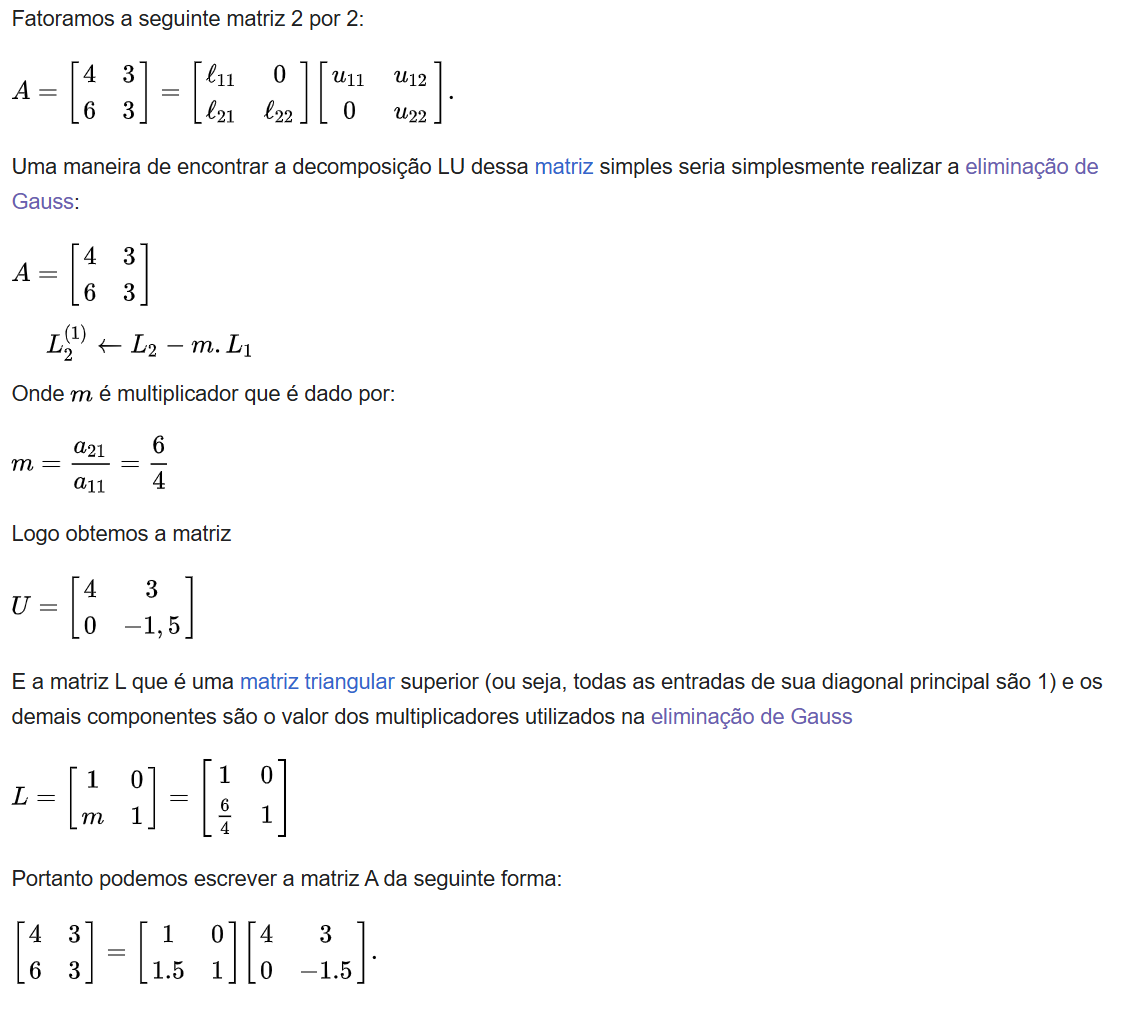

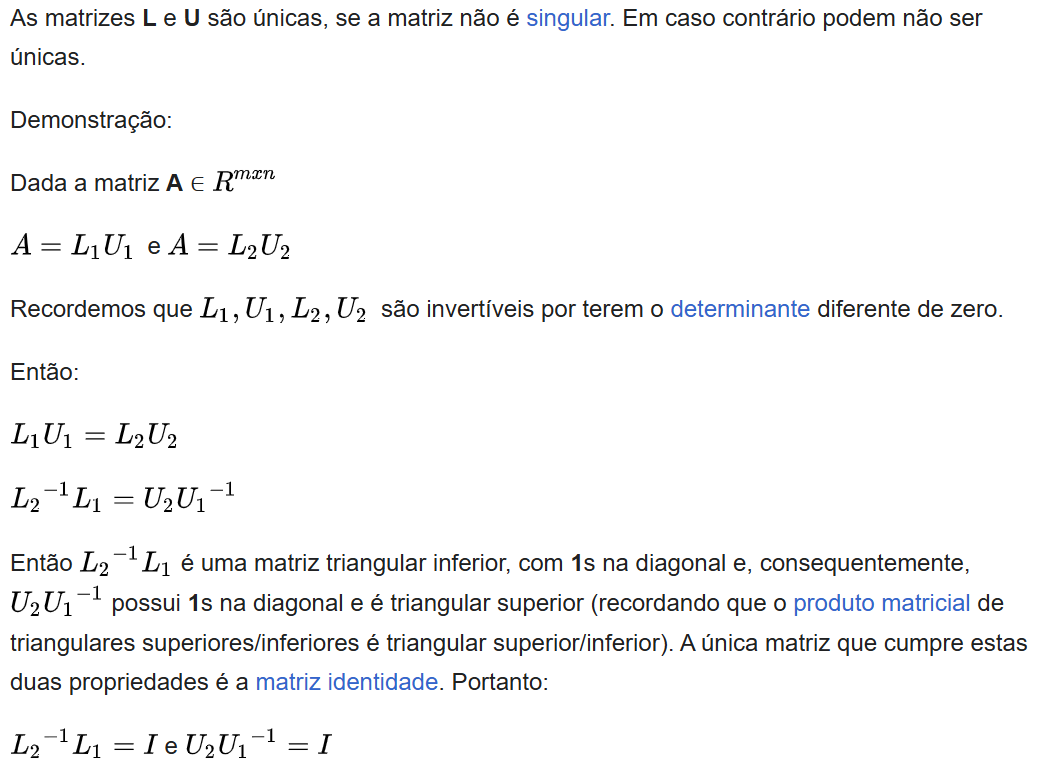

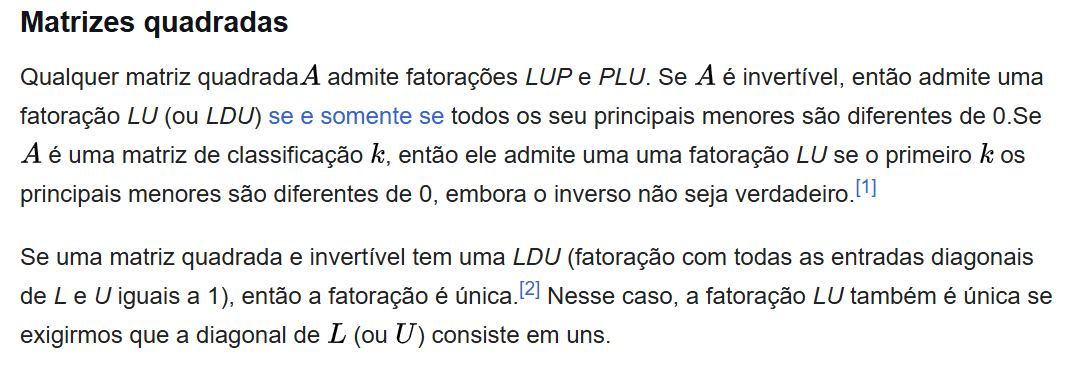

## Exercício 3:

In [ ]:
"""
3) Adapte os códigos anteriores para desenvolver uma rotina que calcula a fatoração PA=LU 
e outra para resolver um sistema linear Ax=b utilizando esta fatoração. 
Represente a matriz de permutação P como uma permutação do vetor [1;2;...;n].
"""

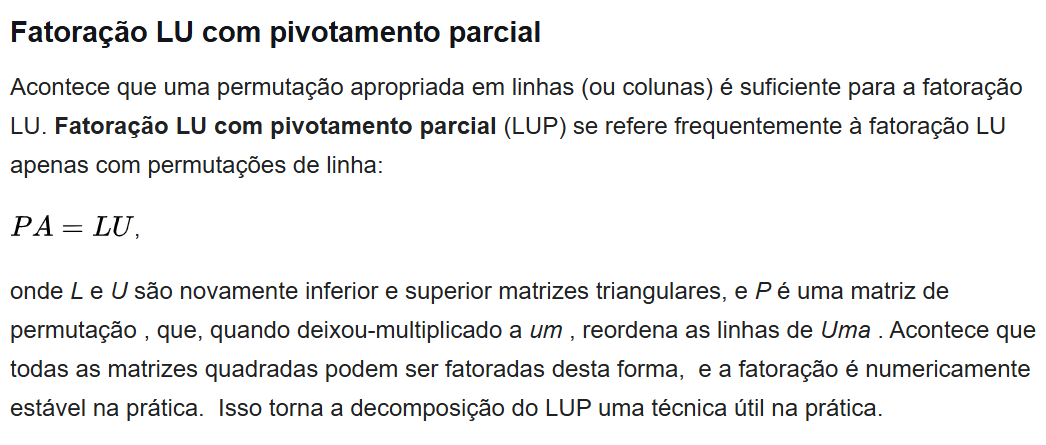

# Exercício 4

In [1]:
import numpy as np

matrizA = np.array(
    [[0, 1, -1, 1], [1, 1, -1, 2], [-1, -1, 1, 0], [1, 2, 0, 2]], dtype=float
)
b = np.array([8, -20, -2, 4], dtype=float)
n = len(matrizA)

print("=" * 50)
print("FATORAÇÃO PA = LU  (passo a passo)")
print("=" * 50)
print(f"\nMatriz A inicial:\n{matrizA}")
print(f"\nVetor b inicial: {b}")

P = np.arange(1, n + 1)
print(f"\nVetor de permutação P inicial: {P}")

for j in range(0, n - 1):
    print(f"\n{'─' * 50}")
    print(f"PASSO j = {j}:")
    print(f"{'─' * 50}")

    # Pivoteamento parcial
    coluna = matrizA[j:n, j]
    print(f"\n  Coluna {j} (da linha {j} em diante): {coluna}")
    print(f"  Valores absolutos: {np.abs(coluna)}")

    indicePivo = np.argmax(np.abs(coluna)) + j
    print(f"  Índice do pivô (maior valor absoluto): {indicePivo}")

    if indicePivo != j:
        print(f"\n  Troca de linhas {j} ↔ {indicePivo}:")
        matrizA[[j, indicePivo]] = matrizA[[indicePivo, j]]
        P[[j, indicePivo]] = P[[indicePivo, j]]
        print(f"  A após troca:\n{matrizA}")
        print(f"  P após troca: {P}")
    else:
        print(f"\n  Sem troca de linhas (pivô já está na posição correta)")

    print(f"\n  Pivô: A[{j},{j}] = {matrizA[j, j]}")

    for i in range(j + 1, n):
        fatorAlfa = matrizA[i, j] / matrizA[j, j]
        print(
            f"\n  → Linha {i}: α = A[{i},{j}] / A[{j},{j}] = {matrizA[i, j]} / {matrizA[j, j]} = {fatorAlfa}"
        )

        matrizA[i, j] = fatorAlfa

        for k in range(j + 1, n):
            matrizA[i, k] -= fatorAlfa * matrizA[j, k]

        print(f"    Linha {i} atualizada (L e U armazenados): {matrizA[i]}")

    print(f"\n  Matriz A após passo j={j}:\n{matrizA}")

print(f"\n{'=' * 50}")
print("RESULTADO DA FATORAÇÃO:")
print(f"{'=' * 50}")
print(f"\nP = {P}")

# Extraindo L e U para visualização
L = np.eye(n)
U = np.zeros((n, n))
for i in range(n):
    for j2 in range(n):
        if i > j2:
            L[i, j2] = matrizA[i, j2]
        else:
            U[i, j2] = matrizA[i, j2]

print(f"\nL (triangular inferior com 1s na diagonal):\n{L}")
print(f"\nU (triangular superior):\n{U}")

# Verificação: PA = LU
P_matrix = np.zeros((n, n))
for i in range(n):
    P_matrix[i, P[i] - 1] = 1

A_original = np.array(
    [[0, 1, -1, 1], [1, 1, -1, 2], [-1, -1, 1, 0], [1, 2, 0, 2]], dtype=float
)
print(f"\nVerificação: PA =\n{P_matrix @ A_original}")
print(f"\nVerificação: LU =\n{L @ U}")

# Resolução do sistema
print(f"\n{'=' * 50}")
print("RESOLUÇÃO DO SISTEMA Ax = b")
print(f"{'=' * 50}")

b_original = np.array([8, -20, -2, 4], dtype=float)
b_perm = b_original[P - 1]
print(f"\nb original: {b_original}")
print(f"b permutado (Pb): {b_perm}")

# Substituição progressiva: Ly = Pb
print(f"\n{'─' * 50}")
print("Substituição progressiva: Ly = Pb")
print(f"{'─' * 50}")
y = np.zeros(n)
for i in range(n):
    soma = matrizA[i, :i] @ y[:i]
    y[i] = b_perm[i] - soma
    print(f"  y[{i}] = b[{i}] - Σ(L[{i},m]·y[m]) = {b_perm[i]} - {soma} = {y[i]}")

print(f"\ny = {y}")

# Substituição regressiva: Ux = y
print(f"\n{'─' * 50}")
print("Substituição regressiva: Ux = y")
print(f"{'─' * 50}")
x = np.zeros(n)
for i in range(n - 1, -1, -1):
    soma = matrizA[i, i + 1 :] @ x[i + 1 :]
    x[i] = (y[i] - soma) / matrizA[i, i]
    print(
        f"  x[{i}] = (y[{i}] - Σ(U[{i},p]·x[p])) / U[{i},{i}] = ({y[i]} - {soma}) / {matrizA[i, i]} = {x[i]}"
    )

print(f"\n{'=' * 50}")
print(f"SOLUÇÃO FINAL: x = {x}")
print(f"{'=' * 50}")

# Verificação final
print(f"\nVerificação: A·x = {A_original @ x}")
print(f"b original:      {b_original}")

FATORAÇÃO PA = LU  (passo a passo)

Matriz A inicial:
[[ 0.  1. -1.  1.]
 [ 1.  1. -1.  2.]
 [-1. -1.  1.  0.]
 [ 1.  2.  0.  2.]]

Vetor b inicial: [  8. -20.  -2.   4.]

Vetor de permutação P inicial: [1 2 3 4]

──────────────────────────────────────────────────
PASSO j = 0:
──────────────────────────────────────────────────

  Coluna 0 (da linha 0 em diante): [ 0.  1. -1.  1.]
  Valores absolutos: [0. 1. 1. 1.]
  Índice do pivô (maior valor absoluto): 1

  Troca de linhas 0 ↔ 1:
  A após troca:
[[ 1.  1. -1.  2.]
 [ 0.  1. -1.  1.]
 [-1. -1.  1.  0.]
 [ 1.  2.  0.  2.]]
  P após troca: [2 1 3 4]

  Pivô: A[0,0] = 1.0

  → Linha 1: α = A[1,0] / A[0,0] = 0.0 / 1.0 = 0.0
    Linha 1 atualizada (L e U armazenados): [ 0.  1. -1.  1.]

  → Linha 2: α = A[2,0] / A[0,0] = -1.0 / 1.0 = -1.0
    Linha 2 atualizada (L e U armazenados): [-1.  0.  0.  2.]

  → Linha 3: α = A[3,0] / A[0,0] = 1.0 / 1.0 = 1.0
    Linha 3 atualizada (L e U armazenados): [1. 1. 1. 0.]

  Matriz A após passo j=0:
[[ 1